In [1]:
# Add module to path
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from itertools import product
from numba import jit, njit, types
from numba.typed import Dict
import time

from darts.dartboards import generate_dartboard
from darts.stats import expected_score, std_score, gaussian_filter

In [36]:
board_size = 256

In [37]:
board, checkouts = generate_dartboard(board_size)

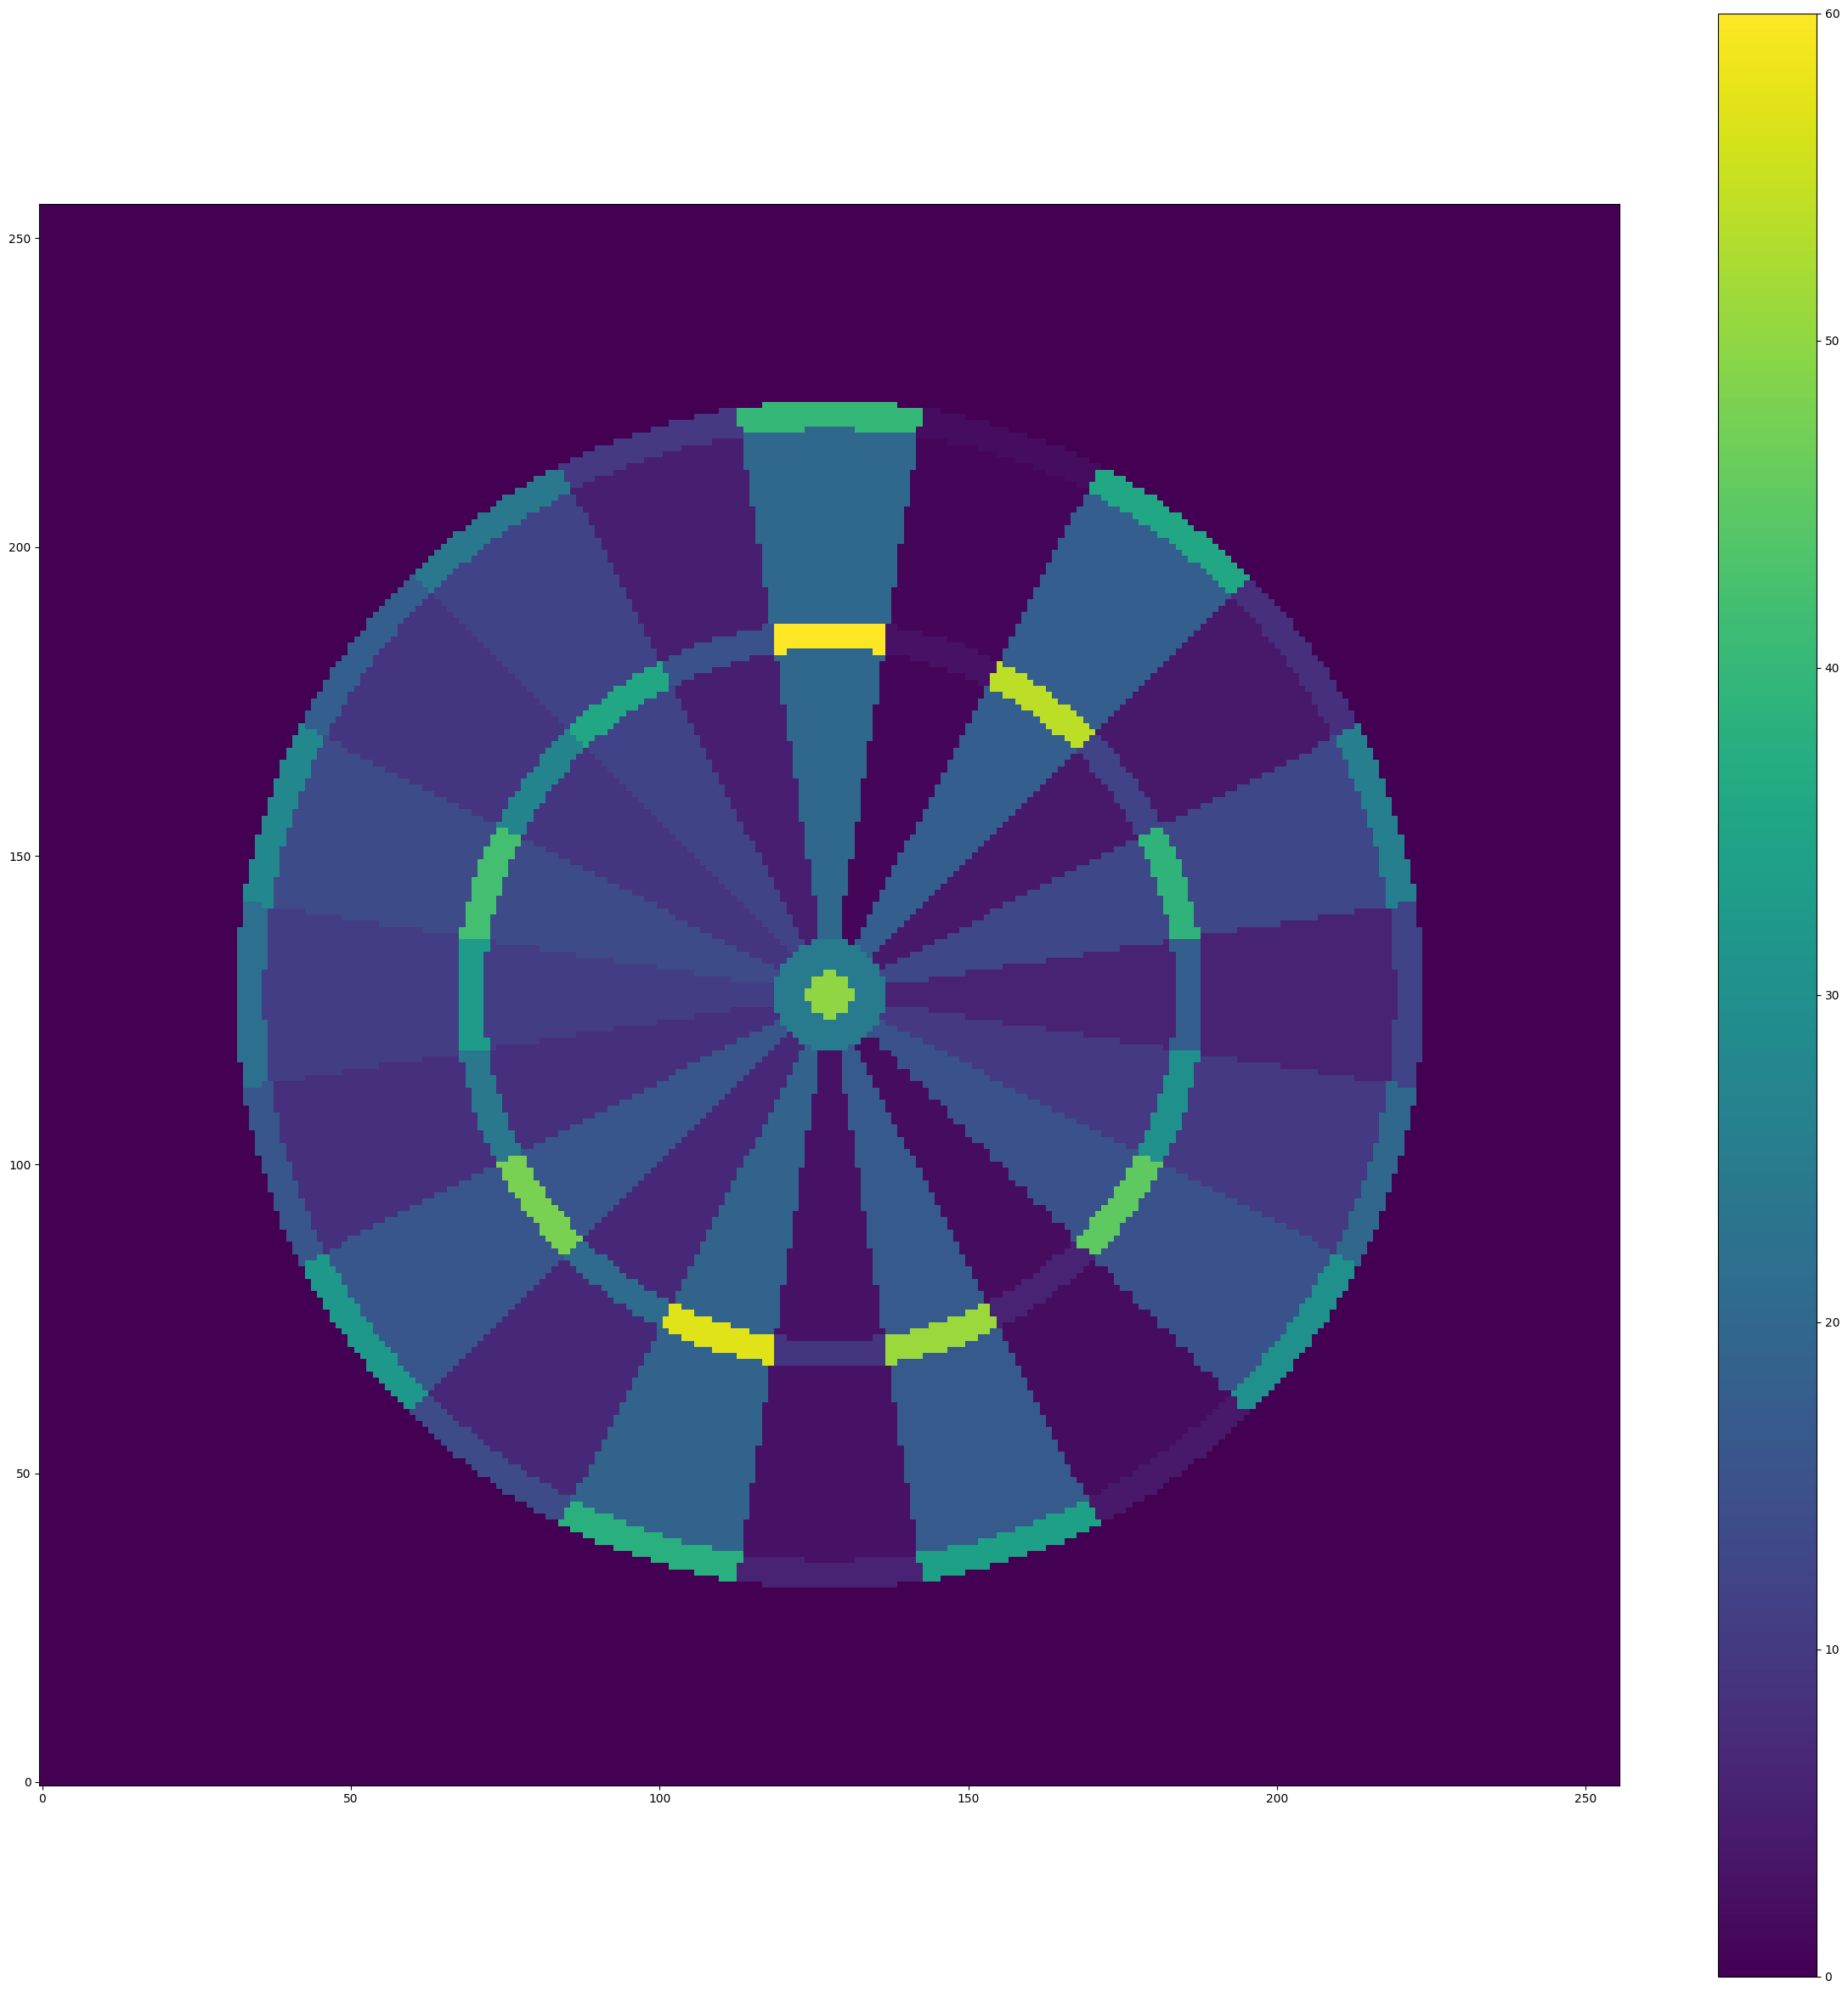

In [38]:
fig, ax = plt.subplots(figsize=(30, 30))
plt.imshow(board, origin='lower')
plt.colorbar()

In [39]:
sigma = 16

In [40]:
mu = np.array([0, 0])
Sigma = sigma*sigma*np.array([[1, 0], [0, 1]])

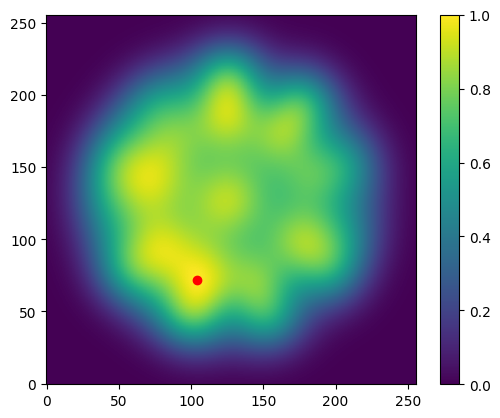

In [41]:
exp = expected_score(board, mu, Sigma, padding=100)
i, j = np.unravel_index(np.argmax(exp), board.shape)
plt.imshow(exp, origin='lower')
plt.scatter(j, i, color='red')
plt.colorbar()

#### States

State $S$ is defined by:
- Current score $s$
- Current throw $t$
- Starting score $u$

Remove some points that are too far from the dartboard

In [42]:
radius_pixels = int(170/225.5*board_size/2)
margin = 2*sigma

In [43]:
centre = np.array([int(board_size/2), int(board_size/2)])
ratio = 1 # board_size//200
points = [(ratio*i, ratio*j) for i, j in product(range(board_size//ratio), range(board_size//ratio))
          if np.linalg.norm(np.array([ratio*i, ratio*j]) - centre) < radius_pixels + margin]

In [44]:
len(points)

51429

In [45]:
len(points)/board_size**2

0.7847442626953125

Let's start by initializing values to 0:

In [46]:
game_start = 501

In [47]:
nonzero_values = {(0, turn, start): 1 for turn, start in product([0, 1, 2], range(game_start+1))}
zero_values = {
    (score, turn, start): 0 for score, turn, start in product(range(1, game_start+1), [0, 1, 2], range(1, game_start+1))
}

In [48]:
values = {**zero_values, **nonzero_values}

In [49]:
## Simplified
values = {score: 0 for score in range(game_start+1)}

In [50]:
len(values)

502

In [51]:
len(points)

51429

### Transition probabilities

Compute transition probabilities
Probability defined by:
- initial state
- final state
- point aimed at

In [52]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [53]:
allowed_scores = np.array([0, 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 30, 32, 33, 34,
        36, 38, 39, 40, 42, 45, 48, 50, 51, 54, 57, 60])

In [54]:
@njit
def prob_score(filt, board, allowed_scores, checkouts):
    probs = {int(s): 0.0 for s in allowed_scores}
    checkout_probs = {int(s): 0.0 for s in allowed_scores}
    for i in range(filt.shape[0]):
        for j in range(filt.shape[1]):
            probs[int(board[i, j])] += filt[i, j]
            
            if checkouts[i, j]:
                checkout_probs[int(board[i, j])] += filt[i, j]
                
    return probs, checkout_probs

In [55]:
def transition_probs(start, board, allowed_scores, checkouts, Sigma):
    gf = gaussian_filter(board, (start[0], start[1]), Sigma)
    gf = gf / np.sum(gf)
    return prob_score(gf, board, allowed_scores, checkouts)

In [56]:
probs = {}
checkout_probs = {}
for start in tqdm(points):
    probs[start], checkout_probs[start] = transition_probs(start - centre, 
                                                           board, 
                                                           allowed_scores,
                                                           checkouts,
                                                           Sigma)

 10%|███████▎                                                                    | 4941/51429 [00:21<03:24, 227.12it/s]


KeyboardInterrupt: 

128: 19seconds

256: 4min 42seconds

360: 14min 48seconds

In [ ]:
import json

# probs_file = f'transition_probs/{board_size}-pixel_{sigma}-sigma-{margin}-margin'
# with open(probs_file, 'w') as f: 
#     json.dump({','.join([str(i) for i in k]): dict(v) for k, v in probs.items()}, f)

In [ ]:
# probs_file = f'transition_probs/checkout_{board_size}-pixel_{sigma}-sigma-{margin}-margin'
# with open(probs_file, 'w') as f: 
#     json.dump({','.join([str(i) for i in k]): dict(v) for k, v in checkout_probs.items()}, f)

In [ ]:
probs[(64, 64)][50]

In [ ]:
checkout_probs[(64, 64)][50]

In [ ]:
@njit
def _compute_state_value(state, values, points, probs, checkout_probs, threshold):
    if state == 0 or state == 1:
        values[state] = 0
        return values
    
    delta = np.inf
    while delta > threshold:
        max_q = -np.inf

        for point in points:
            key = f'{point[0]},{point[1]}'
            p = probs[key]
            cp = checkout_probs[key]
            q = 0
            
            for score in p:
                
                # Valid throw
                if score <= state-2:
                    q += p[score]*(values[state-score] - 1)

                # Checkout
                # Found the problem - point is the aim point, not the scoring point
                elif score == state:
                    q += cp[score]*(values[0] - 1)
                    q += (p[score] - cp[score])*(values[state] - 1)

                # Bust
                else:
                    q += p[score]*(values[state] - 1)

            if q >= max_q:
                max_q = q
        delta = np.abs(max_q - values[state])
        values[state] = max_q
    return values

def compute_values(values, points, probs, checkout_probs, threshold):
    # Setup for numba function
    new_d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
    for k, v in values.items():
        new_d_values[k] = v
        
    d_probs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in probs.items():
        d_probs[','.join([str(x) for x in k])] = v
        
    d_cprobs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in checkout_probs.items():
        d_cprobs[','.join([str(x) for x in k])] = v
        
    for state in tqdm(sorted(values)):
        d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
        for k, v in new_d_values.items():
            d_values[k] = v
        new_d_values = _compute_state_value(state, d_values, np.array(points), d_probs, d_cprobs, threshold)
        
    return new_d_values

In [29]:
# Reinitialize values
values = {k: -12-k/12 for k in values.keys()}
values[0] = 0
values[1] = 0

In [30]:
start = time.time()
values = compute_values(values, points, probs, checkout_probs, 0.001)
end = time.time()

100%|████████████████████████████████████████████████████████████████████████████████| 502/502 [01:20<00:00,  6.22it/s]


In [33]:
print((end - start) // 60, (end - start) % 60)

1.0 26.3342227935791


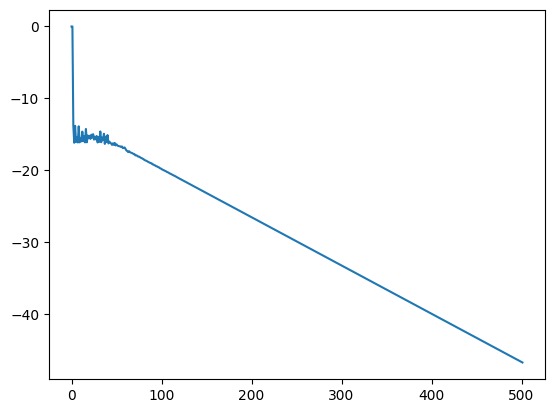

In [34]:
plt.plot(values.keys(), values.values())

In [35]:
list(values.values())

[0.0,
 0.0,
 -13.749920833360058,
 -16.15738496487114,
 -13.80813271947451,
 -16.028836535710834,
 -15.389635657657639,
 -16.115305480617355,
 -13.87274183399095,
 -16.098419112889296,
 -15.499424448259122,
 -15.968418565469232,
 -14.608798702814962,
 -15.947959388200347,
 -15.276513261146752,
 -16.10093022554436,
 -14.23977660830415,
 -16.091983733119616,
 -15.146744880348226,
 -15.532317225938513,
 -15.188054007364567,
 -15.621703444851818,
 -15.035698050437084,
 -15.439127363968721,
 -14.957447725045567,
 -15.717104532778182,
 -15.308105115315946,
 -15.691659597397228,
 -15.216955924503623,
 -16.1138213780728,
 -15.369304816385478,
 -16.034640851956794,
 -14.590164676918313,
 -16.079117211635875,
 -15.438455722749058,
 -15.739329474516424,
 -14.906799731634218,
 -16.31265353478453,
 -15.311746663777033,
 -16.067301602896915,
 -15.092067645200764,
 -16.249530135986,
 -16.000956726961107,
 -16.127934761732625,
 -16.263268051090765,
 -16.4518159388474,
 -16.23427625322642,
 -16.4511516

In [229]:
@njit
def _compute_policy(values, points, probs, checkout_probs):
    policy = Dict.empty(key_type=types.int32, value_type=types.int32[:])
    
    for state in values:
        if state == 0 or state == 1:
            continue
        max_q = -np.inf
        max_a = None

        for point in points:   
            key = f'{point[0]},{point[1]}'
            p = probs[key]
            cp = checkout_probs[key]
            q = 0
            
            for score in p:
                
                # Valid throw
                if score <= state-2:
                    q += p[score]*(values[state-score] - 1)

                # Checkout
                # Found the problem - point is the aim point, not the scoring point
                elif score == state:
                    q += cp[score]*(values[0] - 1)
                    q += (p[score] - cp[score])*(values[state] - 1)

                # Bust
                else:
                    q += p[score]*(values[state] - 1)
                    
            if q >= max_q:
                max_q = q
                max_a = point
                
        policy[state] = max_a
    return policy

def compute_policy(values, points, probs, checkout_probs):
    d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
    for k, v in values.items():
        d_values[k] = v
        
    d_probs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in probs.items():
        d_probs[','.join([str(x) for x in k])] = v
        
    d_cprobs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in checkout_probs.items():
        d_cprobs[','.join([str(x) for x in k])] = v
    
    if not isinstance(points, np.ndarray):
        points = np.array(points)
        
    return _compute_policy(d_values, points, d_probs, d_cprobs)

In [230]:
policy = compute_policy(values, points, probs, checkout_probs)

In [231]:
import pandas as pd
df = pd.DataFrame([(state, board[*point], point) for state, point in policy.items()], columns=['state', 'target', 'point']).set_index('state')
df.head(50)

,target,point
state,,
2,2.0,"[306, 221]"
3,1.0,"[278, 212]"
4,4.0,"[73, 258]"
5,1.0,"[273, 210]"
6,6.0,"[45, 180]"
7,3.0,"[77, 180]"
8,8.0,"[257, 287]"
9,1.0,"[276, 210]"
10,10.0,"[308, 139]"


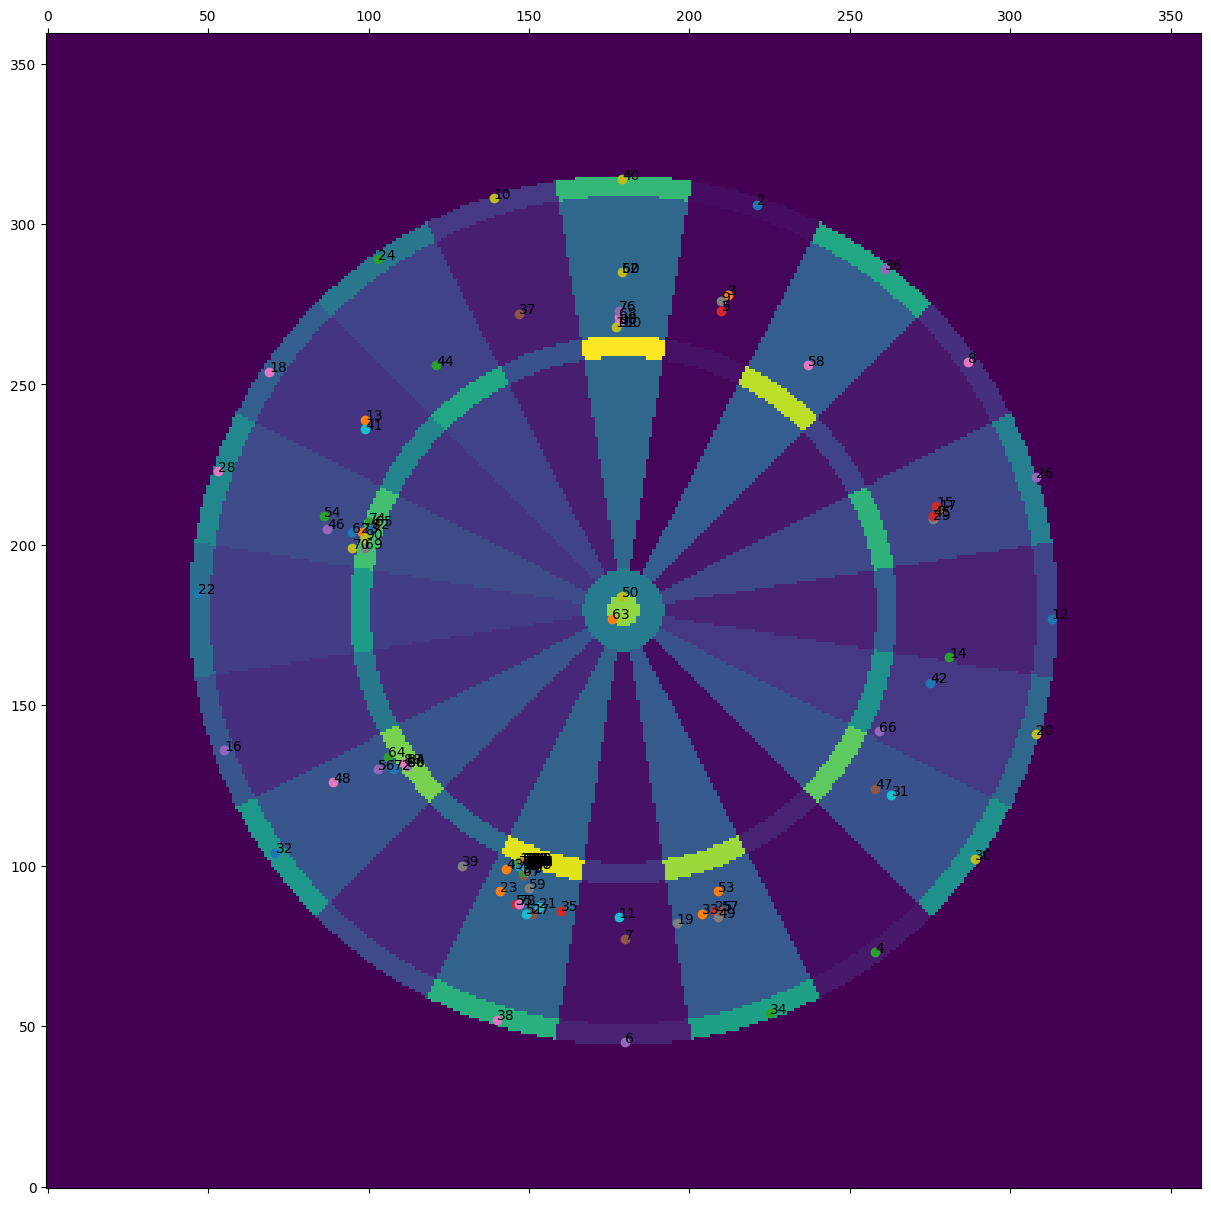

In [232]:
fig, ax = plt.subplots(figsize=(15, 15))
for s, point in policy.items():
    ax.scatter(*point[::-1])
    ax.annotate(s, [point[1], point[0]])
ax.matshow(board, origin='lower')

In [235]:
import pandas as pd
import os

In [236]:
#os.mkdir(f'inf-round_1-player/{board_size}pixel_{sigma}sigma')

In [237]:
#pd.DataFrame(points).to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/points.csv')

In [238]:
#pd.DataFrame(dict(policy)).T.to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/policy.csv')

In [239]:
#pd.DataFrame(values.items(), columns=['state', 'value']).set_index('state').to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/values.csv')